# Photonic Entanglement Characterization Workflow

This notebook demonstrates an end-to-end two-qubit photonic analysis workflow with the current `pec` package. It uses representative Bell-state tomography counts from the repository notebooks and shows how to structure lab data, reconstruct a density matrix, evaluate Bell-state overlap, and report CHSH quantities in a clean, experiment-facing format.

## Workflow

The analysis below follows the same broad sequence used in the original notebooks:

1. import the package from `src/`,
2. standardize a lab-style count table,
3. reconstruct a physical two-qubit state,
4. compute purity and Bell-state fidelities,
5. compute CHSH correlators and the resulting `S` value,
6. present the reconstructed state and derived quantities with compact plots.

In [1]:
from pathlib import Path
import sys

search_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next((path for path in search_roots if (path / "src" / "pec").exists()), None)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing src/pec.")

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Repository root: {repo_root}")
print(f"Using package source: {src_path}")

Repository root: c:\Users\omaru\photonic-entanglement-characterization
Using package source: c:\Users\omaru\photonic-entanglement-characterization\src


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

from pec import bell
from pec import chsh
from pec import io
from pec import metrics
from pec import plotting
from pec import states
from pec import tomography

np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = "{:.4f}".format

## 1. Structure Bell-tomography count data

This example uses the 16-setting two-qubit coincidence table from `Bell_PreLab-Final.ipynb`. In routine use, the same workflow can start from `pec.io.load_counts_table(...)` on a CSV, TSV, or spreadsheet export. To keep this notebook self-contained, the table is created in memory in a spreadsheet-like form and then standardized with `pec.io`.

In [3]:
raw_tomography_export = pd.DataFrame(
    {
        "Measurement State": [
            "HH", "HV", "VH", "VV",
            "HD", "HL", "DH", "RH",
            "DD", "RD", "RL", "DR",
            "DV", "RV", "VD", "VL",
        ],
        "Coincidence Counts": [
            34749, 324, 444, 35805,
            17238, 16722, 16901, 16324,
            32028, 15132, 33586, 17932,
            13441, 17521, 13171, 17170,
        ],
    }
)

# For a real spreadsheet export, the same standardized table can be loaded with:
# counts_table = io.load_counts_table(repo_root / "path" / "bell_tomography_counts.csv")

counts_table = io.standardize_counts_table(raw_tomography_export)
tomography_counts = io.counts_dict_from_table(raw_tomography_export)

counts_table

,counts
label,
HH,34749
HV,324
VH,444
VV,35805
HD,17238
HL,16722
DH,16901
RH,16324
DD,32028


(<Figure size 960x400 with 1 Axes>,
 <Axes: title={'center': 'Two-qubit tomography coincidence counts'}, xlabel='Measurement', ylabel='Coincidence counts'>)

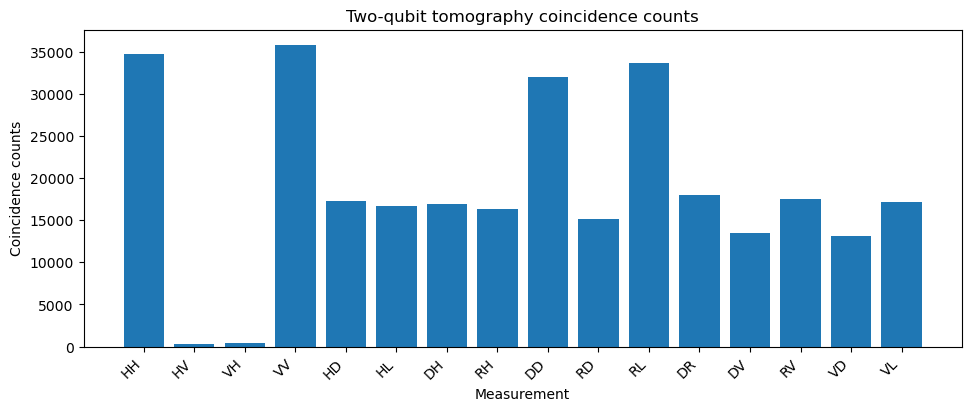

In [4]:
plotting.plot_coincidence_counts(
    counts_table["counts"],
    title="Two-qubit tomography coincidence counts",
    ylabel="Coincidence counts",
)

## 2. Assemble measurement operators and reconstruct the state

The tomography helpers convert polarization labels such as `HH`, `RL`, or `DV` into projectors automatically. For raw coincidence counts, the physically constrained maximum-likelihood path is the appropriate high-level entry point.

In [5]:
measurement_labels = list(counts_table.index)
measurement_operators = tomography.measurement_projectors_from_labels(measurement_labels)

rho_reconstructed = tomography.reconstruct_density_matrix(
    tomography_counts,
    measurement_operators=measurement_operators,
    measurement_labels=measurement_labels,
    method="mle",
)

pd.DataFrame(
    rho_reconstructed,
    index=["HH", "HV", "VH", "VV"],
    columns=["HH", "HV", "VH", "VV"],
)

,HH,HV,VH,VV
HH,0.5037-0.0000j,-0.0218-0.0113j,-0.0252+0.0189j,0.4660-0.0227j
HV,-0.0218+0.0113j,0.0052+0.0000j,0.0041+0.0017j,-0.0328+0.0056j
VH,-0.0252-0.0189j,0.0041-0.0017j,0.0072-0.0000j,-0.0398-0.0112j
VV,0.4660+0.0227j,-0.0328-0.0056j,-0.0398+0.0112j,0.4839+0.0000j


## 3. Summarize the reconstructed state

A useful first summary is trace, purity, and fidelity to a target Bell state. The same summary can also include the CHSH value for a standard set of analyzer directions in the `x-z` plane.

In [6]:
z_axis = bell.unit_vector(0.0, 0.0)
x_axis = bell.unit_vector(np.pi / 2.0, 0.0)
b_axis = (z_axis + x_axis) / np.sqrt(2.0)
bp_axis = (z_axis - x_axis) / np.sqrt(2.0)

phi_plus = states.bell_state("phi_plus")
purity_value = metrics.purity(rho_reconstructed)
phi_plus_fidelity = metrics.fidelity_pure(rho_reconstructed, phi_plus)

summary = tomography.reconstruction_summary(
    rho_reconstructed,
    target_state=phi_plus,
    chsh_settings=(z_axis, x_axis, b_axis, bp_axis),
)

summary_table = pd.DataFrame(
    {
        "Quantity": [
            "Trace",
            "Purity",
            "Fidelity to Phi+",
            "Dominant Bell state",
            "CHSH S",
        ],
        "Value": [
            summary["trace"],
            purity_value,
            phi_plus_fidelity,
            summary["dominant_bell_state"],
            summary["chsh_s"],
        ],
    }
)

summary_table

,Quantity,Value
0,Trace,1.0000
1,Purity,0.9321
2,Fidelity to Phi+,0.9598
3,Dominant Bell state,phi_plus
4,CHSH S,2.7086


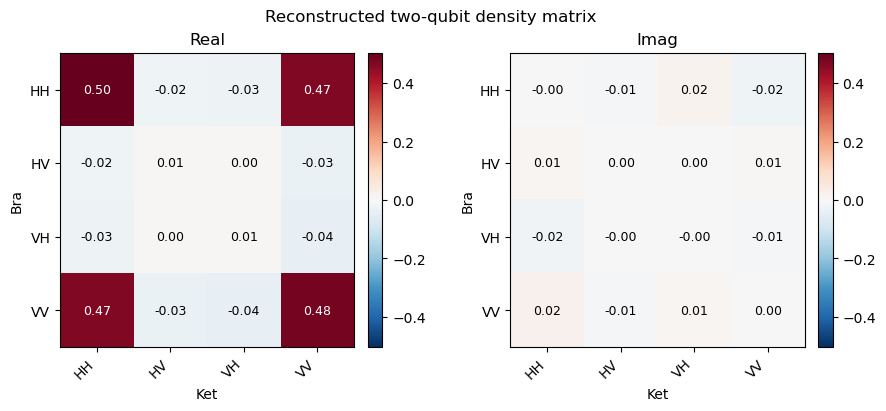

In [7]:
plotting.plot_density_matrix(
    rho_reconstructed,
    title="Reconstructed two-qubit density matrix",
    annotate=True,
    colorbar=True,
)

## 4. Bell-state analysis

Bell-state fidelities quantify how closely the reconstructed state aligns with the canonical entangled basis. A state dominated by `Phi+` is consistent with the Bell-pair preparation used in the source notebook.

,Fidelity
Bell state,
Phi+,0.9598
Phi-,0.0278
Psi+,0.0103
Psi-,0.0021


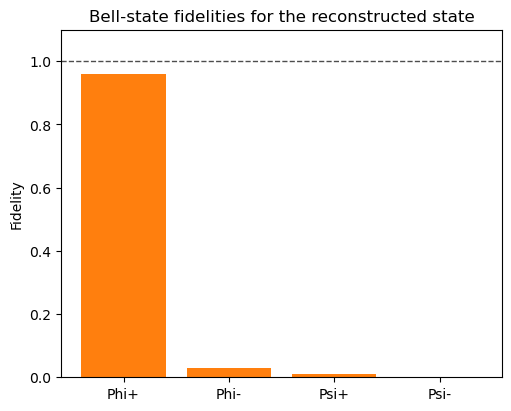

In [8]:
bell_fidelities = bell.bell_state_fidelities(rho_reconstructed)

bell_fidelity_table = pd.DataFrame(
    {
        "Bell state": ["Phi+", "Phi-", "Psi+", "Psi-"],
        "Fidelity": [
            bell_fidelities["phi_plus"],
            bell_fidelities["phi_minus"],
            bell_fidelities["psi_plus"],
            bell_fidelities["psi_minus"],
        ],
    }
).set_index("Bell state")

display(bell_fidelity_table)
plotting.plot_bell_state_fidelities(
    bell_fidelities,
    title="Bell-state fidelities for the reconstructed state",
)

## 5. CHSH correlators and `S`

For a Bell-like state, the standard `x-z` plane settings `a = z`, `a' = x`, `b = (z + x) / sqrt(2)`, and `b' = (z - x) / sqrt(2)` provide the textbook CHSH evaluation. The correlators and `S` below are computed directly from the reconstructed density matrix.

,Value
Quantity,
"E(a,b)",0.7151
"E(a,b')",0.6640
"E(a',b)",0.6755
"E(a',b')",-0.6540
S,2.7086


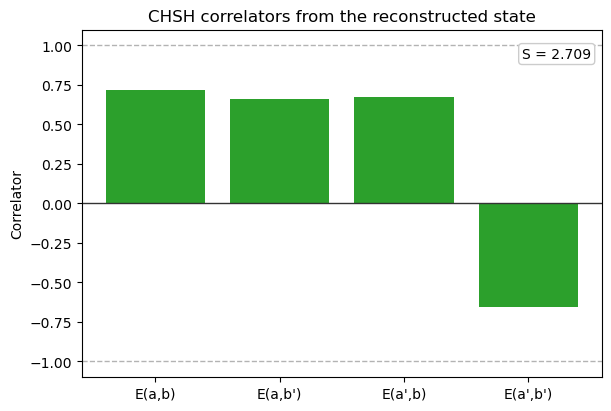

In [9]:
chsh_correlators = chsh.correlators_from_rho(
    rho_reconstructed,
    z_axis,
    x_axis,
    b_axis,
    bp_axis,
)
s_value = chsh.chsh_s_from_rho(
    rho_reconstructed,
    z_axis,
    x_axis,
    b_axis,
    bp_axis,
)

chsh_table = pd.DataFrame(
    {
        "Quantity": ["E(a,b)", "E(a,b')", "E(a',b)", "E(a',b')", "S"],
        "Value": [
            chsh_correlators["ab"],
            chsh_correlators["abp"],
            chsh_correlators["apb"],
            chsh_correlators["apbp"],
            s_value,
        ],
    }
).set_index("Quantity")

display(chsh_table)
plotting.plot_chsh_correlators(
    chsh_correlators,
    title="CHSH correlators from the reconstructed state",
)

## Interpretation

This notebook collects the core photonic characterization outputs in one place: a standardized lab-style count table, a physical two-qubit density matrix, Bell-basis fidelities, and a CHSH estimate. In a typical Bell-pair experiment, a dominant `Phi+` fidelity together with `|S| > 2` indicates entanglement and Bell-inequality violation, while the density-matrix heatmap provides an immediate visual check of the reconstructed coherence structure.

## 6. Waveplate-Theory Validation

This section checks whether the waveplate settings predicted for the CHSH analyzers reproduce the intended measurement observables in theory. It reuses the same Bloch directions `a = z`, `a' = x`, `b = (z + x) / sqrt(2)`, and `b' = (z - x) / sqrt(2)` used above, and then compares the resulting CHSH value against the direct target-observable calculation.

In [10]:
from pec import waveplates

paulis = states.pauli_matrices()


def observable_from_direction(direction):
    direction = np.asarray(direction, dtype=np.float64).reshape(-1)
    direction = direction / np.linalg.norm(direction)
    return (
        direction[0] * paulis["X"]
        + direction[1] * paulis["Y"]
        + direction[2] * paulis["Z"]
    )


def observable_from_basis(positive_state, negative_state):
    return states.projector(positive_state) - states.projector(negative_state)


def correlator_from_observables(rho, alice_observable, bob_observable):
    return float(np.real(np.trace(np.kron(alice_observable, bob_observable) @ rho)))


def chsh_from_observables(rho, a_observable, ap_observable, b_observable, bp_observable):
    return {
        "ab": correlator_from_observables(rho, a_observable, b_observable),
        "abp": correlator_from_observables(rho, a_observable, bp_observable),
        "apb": correlator_from_observables(rho, ap_observable, b_observable),
        "apbp": correlator_from_observables(rho, ap_observable, bp_observable),
    }


def observable_diagnostics(target_direction, recovered_positive_state, recovered_negative_state):
    target_direction = np.asarray(target_direction, dtype=np.float64).reshape(-1)
    target_direction = target_direction / np.linalg.norm(target_direction)
    recovered_direction = waveplates.bloch_direction_from_state(recovered_positive_state)

    target_positive_state, target_negative_state = waveplates.measurement_basis_for_bloch_direction(target_direction)
    target_observable = observable_from_direction(target_direction)
    recovered_observable = observable_from_basis(recovered_positive_state, recovered_negative_state)

    alignment = float(np.dot(recovered_direction, target_direction))
    if alignment > 1.0 - 1e-6:
        orientation = "matches target"
    elif alignment < -1.0 + 1e-6:
        orientation = "matches opposite"
    else:
        orientation = "mismatch"

    return {
        "target_direction": target_direction,
        "recovered_direction": recovered_direction,
        "alignment": alignment,
        "orientation": orientation,
        "positive_projector_error": float(
            np.linalg.norm(states.projector(target_positive_state) - states.projector(recovered_positive_state))
        ),
        "negative_projector_error": float(
            np.linalg.norm(states.projector(target_negative_state) - states.projector(recovered_negative_state))
        ),
        "observable_error_to_target": float(np.linalg.norm(recovered_observable - target_observable)),
        "observable_error_to_opposite": float(np.linalg.norm(recovered_observable + target_observable)),
    }

In [11]:
chsh_directions = {
    "a": z_axis,
    "a'": x_axis,
    "b": b_axis,
    "b'": bp_axis,
}

ideal_observables = {
    label: observable_from_direction(direction)
    for label, direction in chsh_directions.items()
}
ideal_correlators = chsh_from_observables(
    rho_reconstructed,
    ideal_observables["a"],
    ideal_observables["a'"],
    ideal_observables["b"],
    ideal_observables["b'"],
)
S_ideal = chsh.chsh_s_value(ideal_correlators)

waveplate_settings_rows = []
observable_diagnostic_rows = []
waveplate_observables = {}

for index, (label, direction) in enumerate(chsh_directions.items()):
    qwp_angle, hwp_angle, fit_error = waveplates.waveplate_settings_for_bloch_direction(
        direction,
        seed=11 + index,
    )
    analyzer = waveplates.analyzer_unitary_from_waveplates(qwp_angle, hwp_angle)
    recovered_positive_state, recovered_negative_state = waveplates.measurement_basis_from_waveplates(
        qwp_angle,
        hwp_angle,
    )
    recovered_observable = observable_from_basis(recovered_positive_state, recovered_negative_state)
    waveplate_observables[label] = recovered_observable

    diagnostics = observable_diagnostics(direction, recovered_positive_state, recovered_negative_state)

    waveplate_settings_rows.append(
        {
            "Analyzer": label,
            "QWP (deg)": qwp_angle,
            "HWP (deg)": hwp_angle,
            "Fit error": fit_error,
            "Unitary error": float(np.linalg.norm(analyzer.conj().T @ analyzer - paulis["I"])),
        }
    )
    observable_diagnostic_rows.append(
        {
            "Analyzer": label,
            "Target direction": np.array2string(diagnostics["target_direction"], precision=4, suppress_small=True),
            "Recovered direction": np.array2string(diagnostics["recovered_direction"], precision=4, suppress_small=True),
            "Alignment": diagnostics["alignment"],
            "Orientation": diagnostics["orientation"],
            "||O_rec - O_target||": diagnostics["observable_error_to_target"],
            "||O_rec + O_target||": diagnostics["observable_error_to_opposite"],
            "Positive projector error": diagnostics["positive_projector_error"],
            "Negative projector error": diagnostics["negative_projector_error"],
        }
    )

waveplate_settings_table = pd.DataFrame(waveplate_settings_rows).set_index("Analyzer")
observable_diagnostics_table = pd.DataFrame(observable_diagnostic_rows).set_index("Analyzer")

display(waveplate_settings_table)
display(observable_diagnostics_table)

,QWP (deg),HWP (deg),Fit error,Unitary error
Analyzer,,,,
a,0.0000,0.0000,0.0000,0.0000
a',0.0000,22.5000,0.0000,0.0000
b,0.0000,101.2500,0.0000,0.0000
b',0.0000,78.7500,0.0000,0.0000


,Target direction,Recovered direction,Alignment,Orientation,||O_rec - O_target||,||O_rec + O_target||,Positive projector error,Negative projector error
Analyzer,,,,,,,,
a,[0. 0. 1.],[0. 0. 1.],1.0000,matches target,0.0000,2.8284,0.0000,0.0000
a',[1. 0. 0.],[ 1. 0. -0.],1.0000,matches target,0.0000,2.8284,0.0000,0.0000
b,[0.7071 0. 0.7071],[0.7071 0. 0.7071],1.0000,matches target,0.0000,2.8284,0.0000,0.0000
b',[-0.7071 0. 0.7071],[-0.7071 -0. 0.7071],1.0000,matches target,0.0000,2.8284,0.0000,0.0000


In [12]:
waveplate_correlators = chsh_from_observables(
    rho_reconstructed,
    waveplate_observables["a"],
    waveplate_observables["a'"],
    waveplate_observables["b"],
    waveplate_observables["b'"],
)
S_waveplate = chsh.chsh_s_value(waveplate_correlators)

waveplate_validation_table = pd.DataFrame(
    {
        "Ideal target observable": [
            ideal_correlators["ab"],
            ideal_correlators["abp"],
            ideal_correlators["apb"],
            ideal_correlators["apbp"],
            S_ideal,
        ],
        "Waveplate-implied observable": [
            waveplate_correlators["ab"],
            waveplate_correlators["abp"],
            waveplate_correlators["apb"],
            waveplate_correlators["apbp"],
            S_waveplate,
        ],
    },
    index=["E(a,b)", "E(a,b')", "E(a',b)", "E(a',b')", "S"],
)
waveplate_validation_table["Absolute difference"] = np.abs(
    waveplate_validation_table["Waveplate-implied observable"]
    - waveplate_validation_table["Ideal target observable"]
)

print(f"S_ideal = {S_ideal:.6f}")
print(f"S_waveplate = {S_waveplate:.6f}")
display(waveplate_validation_table)

S_ideal = 2.708596
S_waveplate = 2.708596


,Ideal target observable,Waveplate-implied observable,Absolute difference
"E(a,b)",0.7151,0.7151,0.0000
"E(a,b')",0.6640,0.6640,0.0000
"E(a',b)",0.6755,0.6755,0.0000
"E(a',b')",-0.6540,-0.6540,0.0000
S,2.7086,2.7086,0.0000


### Waveplate Interpretation

If `S_ideal` and `S_waveplate` agree to numerical precision, then the waveplate-setting code is theoretically consistent with the intended CHSH analyzer directions. If the target-observable calculation gives `S_ideal > 2` but the waveplate-implied calculation drops below `2`, then the most likely explanation is a convention mismatch in waveplate order, angle sign, PBS port labeling, or basis mapping. The observable diagnostics above help distinguish a clean sign flip from a deeper analyzer-convention mismatch.